# n(z) by DESI target class

Loads catalog rows from `spectra_shuffled/` (flux/ivar not needed) and plots
the redshift distribution for each main target class.

In [1]:
import glob
import os
import sys

import fitsio
import numpy as np
import matplotlib.pyplot as plt

# ---- config ----------------------------------------------------------------
SPECTRA_DIR = '../spectra_shuffled/'
N_FILES     = 20          # number of spec-*.fits files to load (~500 spectra each)
ZMIN, ZMAX  = 0.0, 2.0   # redshift range for histograms
N_BINS      = 80

In [2]:
# ---- load catalog columns only (fast — no flux/ivar) -----------------------
files = sorted(glob.glob(os.path.join(SPECTRA_DIR, 'spec-*.fits')))[:N_FILES]
if not files:
    raise FileNotFoundError(f'No spec-*.fits files in {SPECTRA_DIR!r}')

cats = []
for path in files:
    with fitsio.FITS(path) as f:
        cats.append(f['cat'].read(columns=['z', 'desi_target', 'program']))
cat = np.concatenate(cats)

z           = cat['z'].astype(np.float32)
desi_target = cat['desi_target'].astype(np.uint64)
program     = cat['program']     # bytes: b'dark' or b'bright'

print(f'Loaded {len(z):,} spectra from {len(files)} files')
print(f'  z range: [{z.min():.3f}, {z.max():.3f}]')
print(f'  programs: {dict(zip(*np.unique(program, return_counts=True)))}')

Loaded 9,997 spectra from 20 files
  z range: [-0.004, 1.697]
  programs: {np.str_('bright'): np.int64(37), np.str_('dark'): np.int64(9960)}


In [3]:
# ---- target class definitions (DESI_TARGET bitmask) -----------------------
# Primary dark-time targets
LRG_BITS = [0, 16]          # LRG, LRG_LOWDENS
ELG_BITS = [1, 5, 6, 17, 19]  # ELG, ELG_LOP, ELG_HIP, ELG_LOP_NORTH/SOUTH
QSO_BITS = [2, 7, 8, 9]    # QSO and sub-classes
# Primary bright-time targets
BGS_BITS = [60, 61, 62]     # BGS_FAINT, BGS_BRIGHT, BGS_FAINT_HIP

def any_bit(arr, bits):
    mask = np.zeros(len(arr), dtype=bool)
    for b in bits:
        mask |= (arr & np.uint64(1 << b)) != 0
    return mask

masks = {
    'LRG':  any_bit(desi_target, LRG_BITS),
    'ELG':  any_bit(desi_target, ELG_BITS),
    'QSO':  any_bit(desi_target, QSO_BITS),
    'BGS':  any_bit(desi_target, BGS_BITS),
}

for name, m in masks.items():
    print(f'  {name}: {m.sum():5,} spectra')

  LRG: 3,467 spectra
  ELG: 5,634 spectra
  QSO: 2,751 spectra
  BGS: 1,157 spectra


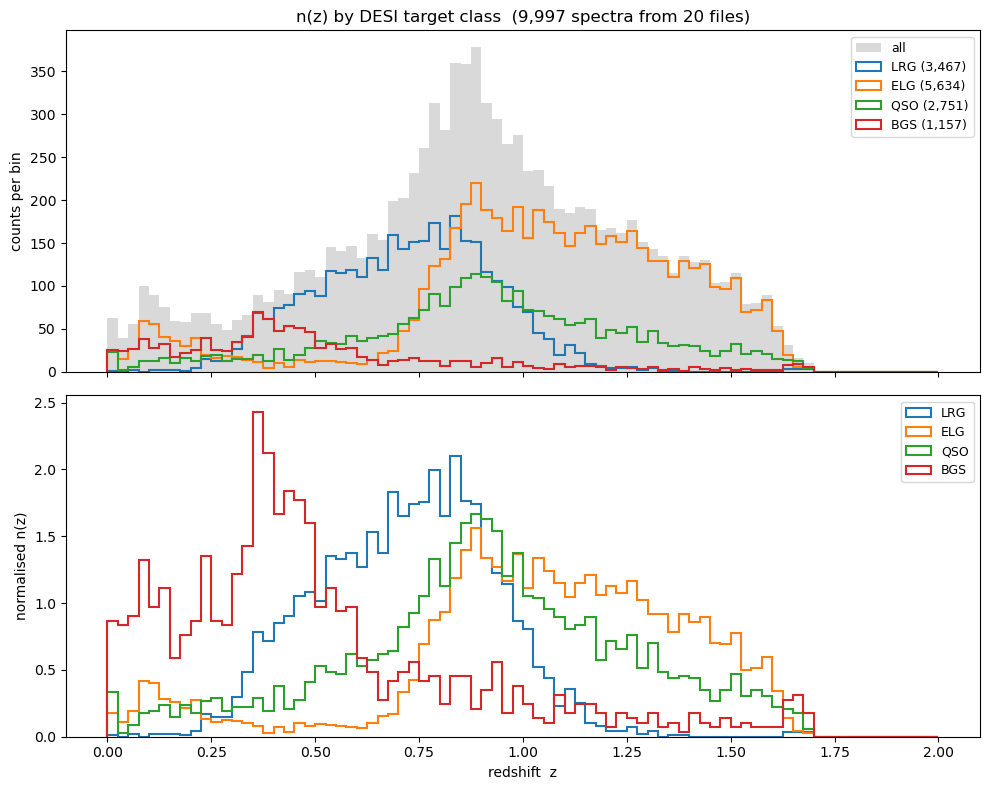

In [4]:
# ---- plot ------------------------------------------------------------------
colors = {'LRG': 'C0', 'ELG': 'C1', 'QSO': 'C2', 'BGS': 'C3'}
bins = np.linspace(ZMIN, ZMAX, N_BINS + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top panel: raw counts
ax = axes[0]
ax.hist(z, bins=bins, histtype='stepfilled', alpha=0.15, color='k', label='all')
for name, m in masks.items():
    ax.hist(z[m], bins=bins, histtype='step', lw=1.5,
            color=colors[name], label=f'{name} ({m.sum():,})')
ax.set_ylabel('counts per bin')
ax.legend(fontsize=9)
ax.set_title(f'n(z) by DESI target class  ({len(z):,} spectra from {len(files)} files)')

# Bottom panel: normalised (density)
ax = axes[1]
for name, m in masks.items():
    if m.sum() > 10:
        ax.hist(z[m], bins=bins, histtype='step', lw=1.5, density=True,
                color=colors[name], label=name)
ax.set_xlabel('redshift  z')
ax.set_ylabel('normalised n(z)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

AttributeError: 'numpy.str_' object has no attribute 'decode'

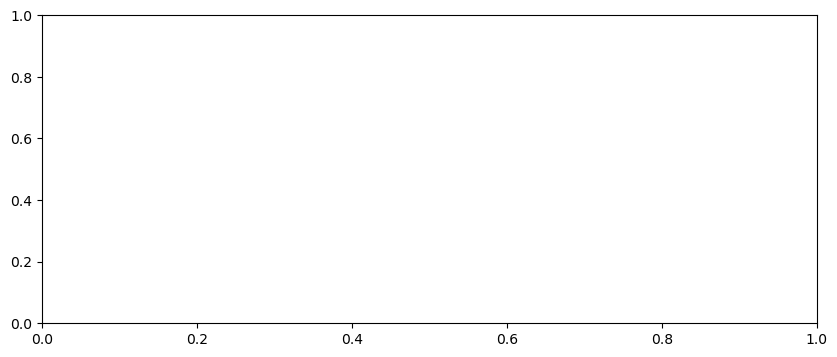

In [6]:
# ---- split by program (dark / bright) -------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
bins_fine = np.linspace(ZMIN, ZMAX, N_BINS * 2 + 1)
for prog, ls in [('dark', '-'), ('bright', '--')]:
    m = np.array([p.decode().strip() == prog for p in program])
    if m.sum() > 0:
        ax.hist(z[m], bins=bins_fine, histtype='step', lw=1.5,
                linestyle=ls, density=True, label=f'{prog} ({m.sum():,})')
ax.set_xlabel('redshift  z')
ax.set_ylabel('normalised n(z)')
ax.legend()
ax.set_title('n(z) split by program')
plt.tight_layout()
plt.show()